### Experimental Setup

In [1]:
FEATURE_SELECTION_METHOD = "Corr"
DEEP_LEARNING_CATEGORY = "Pre_Attention"
MODEL_ARCHITECTURE = "LSTM"
DATASET_NAME = "Opensnoop"

**Developed By:** eDySec Research Team   
**Plartform:** Ubuntu 

All experiments in this notebook were conducted using **Python 3.10** with the following libraries:

`pandas==1.5.3`,  
`scikit-learn==1.2.2`,  
`openpyxl`,  
`numpy==1.23.5`,  
`scipy==1.9.3`,  
`tensorflow==2.11.0`,  
`matplotlib==3.7.1`,  
`seaborn==0.12.2`,  
`joblib==1.3.2`,  
`shap==0.41.0`,  
`lime`,  
`flaml[automl]==2.5.0`,  
`notebook==6.5.6`,  
`pywinpty==2.0.10`  (Only for windows)  `threadpoolctl==3.1.0` (for Ubuntu)   
`terminado==0.17.1`,  
`transformers==4.49.0`.

#### Full Environment Setup: https://github.com/tanzirmehedi/eDySec

These versions were used to ensure **consistent and reproducible experimental results**.

### Import Necessary Packages

In [2]:
# ============================================================
# Standard Library
# ============================================================
import os
import gc
import sys
import time
import warnings

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ============================================================
# Numerical and Data Processing
# ============================================================
import numpy as np
import pandas as pd
import scipy

# ============================================================
# Visualization
# ============================================================
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Scikit-learn
# ============================================================
import sklearn
from scipy.sparse import csr_matrix, hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ============================================================
# TensorFlow / Keras
# ============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)
from tensorflow.keras.layers import (
    BatchNormalization,
    Dense,
    Dropout,
    LSTM,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# ============================================================
# Transformers
# ============================================================
import transformers
from transformers import (
    BertTokenizer,
    GPT2Tokenizer,
    TFBertModel,
    TFGPT2Model,
)

# ============================================================
# AutoML and Model Persistence
# ============================================================
#from flaml import AutoML
import joblib

### Version Checking

In [2]:
print("=" * 60)
print("Python Version")
print("=" * 60)
print(sys.version)

print("\n" + "=" * 60)
print("Core Library Versions")
print("=" * 60)
print(f"NumPy            : {np.__version__}")
print(f"Pandas           : {pd.__version__}")
print(f"Matplotlib       : {matplotlib.__version__}")
print(f"Seaborn          : {sns.__version__}")
print(f"SciPy            : {scipy.__version__}")
print(f"Scikit-learn     : {sklearn.__version__}")
print(f"TensorFlow       : {tf.__version__}")
print(f"Transformers     : {transformers.__version__}")
print(f"Joblib           : {joblib.__version__}")

print("\n" + "=" * 60)
print("Keras Version")
print("=" * 60)
print(f"Keras (tf.keras) : {tf.keras.__version__}")

print("\n" + "=" * 60)
print("CUDA / GPU Info")
print("=" * 60)
print(f"Built with CUDA  : {tf.test.is_built_with_cuda()}")
print(f"GPU Available    : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"GPUs             : {tf.config.list_physical_devices('GPU')}")

Python Version
3.10.20 (main, Mar 11 2026, 17:46:40) [GCC 14.3.0]

Core Library Versions
NumPy            : 1.23.5
Pandas           : 1.5.3
Matplotlib       : 3.7.1
Seaborn          : 0.12.2
SciPy            : 1.9.3
Scikit-learn     : 1.2.2
TensorFlow       : 2.11.0
Transformers     : 4.38.2
Joblib           : 1.3.2

Keras Version
Keras (tf.keras) : 2.11.0

CUDA / GPU Info
Built with CUDA  : True
GPU Available    : True
GPUs             : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### GPU Checking

In [3]:
# ============================================================
# GPU Status and Resource Monitoring
# ============================================================

# Display NVIDIA GPU information including driver version,
# CUDA version, memory usage, and active processes

!nvidia-smi

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Thu Mar 26 17:30:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.54                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               On  |   00000000:01:00.0  On |                  Off |
| 30%   32C    P8             13W /  300W |     566MiB /  49140MiB |      7%      Default |
|           

### GPU Status Checking

In [5]:
# ============================================================
# Detailed System and GPU Diagnostics
# ============================================================

print("=" * 60)
print("TensorFlow Environment Diagnostics")
print("=" * 60)

print(f"Conda Prefix        : {os.environ.get('CONDA_PREFIX')}")
print(f"LD_LIBRARY_PATH     : {os.environ.get('LD_LIBRARY_PATH')}")
print(f"TensorFlow Version  : {tf.__version__}")
print(f"Built with CUDA     : {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"Number of GPUs      : {len(gpus)}")

for idx, gpu in enumerate(gpus):
    print(f"GPU {idx}            : {gpu}")

print("=" * 60)

TensorFlow Environment Diagnostics
Conda Prefix        : /home/n11894571/miniconda3/envs/tf211gpu
LD_LIBRARY_PATH     : /home/n11894571/miniconda3/envs/tf211gpu/lib:
TensorFlow Version  : 2.11.0
Built with CUDA     : True
Number of GPUs      : 1
GPU 0            : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Allocate as Much GPU Memory as Needed

In [6]:
# ============================================================
# Advanced GPU Configuration and Diagnostics
# ============================================================

gpus = tf.config.list_physical_devices('GPU')

print("=" * 60)
print("GPU Configuration")
print("=" * 60)

if gpus:
    print(f"Number of GPUs detected: {len(gpus)}")
    
    try:
        for idx, gpu in enumerate(gpus):
            # Disable memory growth (allocate full GPU memory)
            tf.config.experimental.set_memory_growth(gpu, False)
            print(f"GPU {idx}: Memory growth disabled (full allocation mode)")
    
    except RuntimeError as e:
        print(f"RuntimeError: {e}")
else:
    print("No GPU detected. Using CPU.")

print("=" * 60)

GPU Configuration
Number of GPUs detected: 1
GPU 0: Memory growth disabled (full allocation mode)


### Load QUT-DV25 Dataset

In [3]:
# ============================================================
# Data Loading and Initial Inspection
# ============================================================

# Define the dataset file path
file_path = 'QUT-DV25_'+DATASET_NAME+'_Traces.csv'

# Load the dataset into a pandas DataFrame
data = pd.read_csv(file_path)

# Display the first few rows for initial inspection
data.head()

,Package_Name,Total_Paths,Total_Error,Total_ File_Descriptor,Python_Related_Keywords,Install_Package_Keywords,Root_DIR_Installation,Temporary_DIR_Installation,Home_DIR_Installation,User_Access,Sys_Access,Etc_DIR_Installation,Other_DIR_Installation,Level
0,10Cent10-999.0.4.tar.gz,8045,8045,29,1083,2305,0,71,792,411,1225,151,5395,1
1,10Cent11-999.0.4.tar.gz,4790,4790,12,1616,843,2,87,1118,721,1200,104,1558,1
2,11Cent-999.0.0.tar.gz,26159,26159,27,3299,4536,0,200,2485,1072,1236,450,20716,1
3,11Cent-999.0.1.tar.gz,11194,11194,28,1521,2558,2,97,1035,891,1211,265,7693,1
4,11Cent-999.0.2.tar.gz,13561,13561,35,2656,5265,501,17,1497,1719,1219,291,8317,1


### Clear Backend Session

In [4]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Selected Features

In [5]:
selected_features = ['Total_Paths', 'Total_ File_Descriptor', 'Temporary_DIR_Installation', 'Sys_Access']

### Data Preprocessing

In [6]:
# ============================================================
# Feature Selection and Dataset Preparation
# ============================================================

# Select the predefined feature subset
selected_features_with_target = selected_features.copy()

# Create a feature matrix from the selected features
X = data[selected_features_with_target].copy()

# Define the target variable
y = data['Level']

# ============================================================
# Train–Validation–Test Split (70%–15%–15%)
# ============================================================

# Step 1: Split into training (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split temporary set into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ============================================================
# Dataset Summary
# ============================================================

print(f"Training set shape     : {X_train.shape}")
print(f"Validation set shape   : {X_val.shape}")
print(f"Test set shape         : {X_test.shape}")

Training set shape     : (9989, 4)
Validation set shape   : (2141, 4)
Test set shape         : (2141, 4)


### Setup OUTPUT_DIR

In [7]:
OUTPUT_DIR = "Evaluation_Outputs_"+DATASET_NAME+"_"+FEATURE_SELECTION_METHOD+"_"+DEEP_LEARNING_CATEGORY+"_"+MODEL_ARCHITECTURE
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_DIR

'Evaluation_Outputs_Opensnoop_Corr_Pre_Attention_LSTM'

### Model

In [8]:
# ============================================================
# Define model saving configuration
# ============================================================

SAVE_DIR = OUTPUT_DIR
MODEL_NAME = os.path.join(SAVE_DIR, OUTPUT_DIR + ".h5")


# ==========================
# Convert each row into a single text string
# ==========================
def row_to_text(df):
    texts = []
    for _, row in df.iterrows():
        text = " ".join([f"{col}:{row[col]}" for col in df.columns])
        texts.append(text)
    return texts

train_texts = row_to_text(X_train)
val_texts   = row_to_text(X_val)
test_texts  = row_to_text(X_test)


# ==========================
# Tokenization
# ==========================
max_words = 4000   # vocabulary size
max_len = 10       # sequence length

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_val_seq   = tokenizer.texts_to_sequences(val_texts)
X_test_seq  = tokenizer.texts_to_sequences(test_texts)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")


# ==========================
# Labels
# ==========================
y_train = np.asarray(y_train).astype(np.float32)
y_val   = np.asarray(y_val).astype(np.float32)
y_test  = np.asarray(y_test).astype(np.float32)


# ==========================
# Callbacks
# ==========================
checkpoint_cb = ModelCheckpoint(
    MODEL_NAME,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=200,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor="val_accuracy",
    patience=200,
    restore_best_weights=True
)


# ==========================
# Build LSTM model
# ==========================
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_len,)),

    tf.keras.layers.Embedding(
        input_dim=max_words,
        output_dim=64
    ),

    tf.keras.layers.LSTM(64, return_sequences=False),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])


# ==========================
# Compile model
# ==========================
model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 10, 64)            256000    
                                                                 
 lstm (LSTM)                 (None, 64)                33024     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 291,137
Trainable params: 291,137
Non-trainable params: 0
_________________________________________________________________


### Check sequence length distribution and UPDATE max_len = 95th Percentile

In [9]:
lengths = [len(seq) for seq in X_train_seq]

import numpy as np
print("Mean:", np.mean(lengths))
print("Median:", np.median(lengths))
print("95th percentile:", np.percentile(lengths, 95))
print("Max:", np.max(lengths))

Mean: 14.0
Median: 14.0
95th percentile: 14.0
Max: 14


### Check max_words and choose 1/5 

In [10]:
word_counts = tokenizer.word_counts
print("Total unique tokens:", len(word_counts))

Total unique tokens: 10206


### Compime the Model

In [11]:
# ==========================
# Train model
# ==========================

start_train = time.time()

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=200,
    batch_size=16,
    callbacks=[checkpoint_cb, reduce_lr_cb, early_stop_cb],
    verbose=1
)

end_train = time.time()
training_time = end_train - start_train

Epoch 1/200
619/625 [============================>.] - ETA: 0s - loss: 0.6731 - accuracy: 0.5755
Epoch 1: val_accuracy improved from -inf to 0.61093, saving model to Evaluation_Outputs_Opensnoop_Corr_Pre_Attention_LSTM\Evaluation_Outputs_Opensnoop_Corr_Pre_Attention_LSTM.h5
625/625 [==============================] - 11s 9ms/step - loss: 0.6734 - accuracy: 0.5749 - val_loss: 0.6571 - val_accuracy: 0.6109 - lr: 0.0010
Epoch 2/200
623/625 [============================>.] - ETA: 0s - loss: 0.6100 - accuracy: 0.6681
Epoch 2: val_accuracy did not improve from 0.61093
625/625 [==============================] - 5s 8ms/step - loss: 0.6098 - accuracy: 0.6680 - val_loss: 0.6555 - val_accuracy: 0.6095 - lr: 0.0010
Epoch 3/200
619/625 [============================>.] - ETA: 0s - loss: 0.5161 - accuracy: 0.7171
Epoch 3: val_accuracy did not improve from 0.61093
625/625 [==============================] - 5s 8ms/step - loss: 0.5155 - accuracy: 0.7179 - val_loss: 0.7082 - val_accuracy: 0.6072 - lr: 0.0

625/625 [==============================] - 5s 9ms/step - loss: 0.4189 - accuracy: 0.7575 - val_loss: 0.8103 - val_accuracy: 0.6021 - lr: 0.0010
Epoch 29/200
625/625 [==============================] - ETA: 0s - loss: 0.4188 - accuracy: 0.7565
Epoch 29: val_accuracy did not improve from 0.61093
625/625 [==============================] - 5s 9ms/step - loss: 0.4188 - accuracy: 0.7565 - val_loss: 0.7734 - val_accuracy: 0.6035 - lr: 0.0010
Epoch 30/200
623/625 [============================>.] - ETA: 0s - loss: 0.4186 - accuracy: 0.7576
Epoch 30: val_accuracy did not improve from 0.61093
625/625 [==============================] - 9s 15ms/step - loss: 0.4184 - accuracy: 0.7579 - val_loss: 0.8087 - val_accuracy: 0.6039 - lr: 0.0010
Epoch 31/200
622/625 [============================>.] - ETA: 0s - loss: 0.4188 - accuracy: 0.7561
Epoch 31: val_accuracy did not improve from 0.61093
625/625 [==============================] - 4s 7ms/step - loss: 0.4186 - accuracy: 0.7561 - val_loss: 0.7775 - val_acc

625/625 [==============================] - 6s 9ms/step - loss: 0.4103 - accuracy: 0.7596 - val_loss: 0.8064 - val_accuracy: 0.6067 - lr: 0.0010
Epoch 57/200
623/625 [============================>.] - ETA: 0s - loss: 0.4092 - accuracy: 0.7618
Epoch 57: val_accuracy did not improve from 0.61093
625/625 [==============================] - 6s 9ms/step - loss: 0.4090 - accuracy: 0.7620 - val_loss: 0.8314 - val_accuracy: 0.6044 - lr: 0.0010
Epoch 58/200
621/625 [============================>.] - ETA: 0s - loss: 0.4127 - accuracy: 0.7602
Epoch 58: val_accuracy did not improve from 0.61093
625/625 [==============================] - 6s 9ms/step - loss: 0.4122 - accuracy: 0.7602 - val_loss: 0.7960 - val_accuracy: 0.6049 - lr: 0.0010
Epoch 59/200
621/625 [============================>.] - ETA: 0s - loss: 0.4096 - accuracy: 0.7604
Epoch 59: val_accuracy did not improve from 0.61093
625/625 [==============================] - 6s 9ms/step - loss: 0.4095 - accuracy: 0.7606 - val_loss: 0.8087 - val_accu

Epoch 84/200
624/625 [============================>.] - ETA: 0s - loss: 0.4065 - accuracy: 0.7610
Epoch 84: val_accuracy did not improve from 0.61140
625/625 [==============================] - 6s 9ms/step - loss: 0.4064 - accuracy: 0.7611 - val_loss: 0.8592 - val_accuracy: 0.6067 - lr: 0.0010
Epoch 85/200
623/625 [============================>.] - ETA: 0s - loss: 0.4072 - accuracy: 0.7603
Epoch 85: val_accuracy did not improve from 0.61140
625/625 [==============================] - 6s 9ms/step - loss: 0.4069 - accuracy: 0.7608 - val_loss: 0.8716 - val_accuracy: 0.6058 - lr: 0.0010
Epoch 86/200
624/625 [============================>.] - ETA: 0s - loss: 0.4084 - accuracy: 0.7604
Epoch 86: val_accuracy did not improve from 0.61140
625/625 [==============================] - 6s 9ms/step - loss: 0.4085 - accuracy: 0.7602 - val_loss: 0.8182 - val_accuracy: 0.6063 - lr: 0.0010
Epoch 87/200
621/625 [============================>.] - ETA: 0s - loss: 0.4065 - accuracy: 0.7617
Epoch 87: val_accura

Epoch 112/200
620/625 [============================>.] - ETA: 0s - loss: 0.4056 - accuracy: 0.7627
Epoch 112: val_accuracy did not improve from 0.61140
625/625 [==============================] - 5s 9ms/step - loss: 0.4060 - accuracy: 0.7619 - val_loss: 0.8766 - val_accuracy: 0.6030 - lr: 0.0010
Epoch 113/200
620/625 [============================>.] - ETA: 0s - loss: 0.4061 - accuracy: 0.7625
Epoch 113: val_accuracy did not improve from 0.61140
625/625 [==============================] - 6s 9ms/step - loss: 0.4062 - accuracy: 0.7626 - val_loss: 0.8639 - val_accuracy: 0.6025 - lr: 0.0010
Epoch 114/200
621/625 [============================>.] - ETA: 0s - loss: 0.4060 - accuracy: 0.7622
Epoch 114: val_accuracy did not improve from 0.61140
625/625 [==============================] - 5s 9ms/step - loss: 0.4057 - accuracy: 0.7625 - val_loss: 0.8526 - val_accuracy: 0.6030 - lr: 0.0010
Epoch 115/200
620/625 [============================>.] - ETA: 0s - loss: 0.4060 - accuracy: 0.7630
Epoch 115: va

Epoch 140/200
625/625 [==============================] - ETA: 0s - loss: 0.4051 - accuracy: 0.7628
Epoch 140: val_accuracy did not improve from 0.61140
625/625 [==============================] - 5s 9ms/step - loss: 0.4051 - accuracy: 0.7628 - val_loss: 0.8945 - val_accuracy: 0.6049 - lr: 0.0010
Epoch 141/200
621/625 [============================>.] - ETA: 0s - loss: 0.4050 - accuracy: 0.7633
Epoch 141: val_accuracy did not improve from 0.61140
625/625 [==============================] - 6s 9ms/step - loss: 0.4048 - accuracy: 0.7632 - val_loss: 0.9218 - val_accuracy: 0.6049 - lr: 0.0010
Epoch 142/200
625/625 [==============================] - ETA: 0s - loss: 0.4053 - accuracy: 0.7619
Epoch 142: val_accuracy did not improve from 0.61140
625/625 [==============================] - 6s 9ms/step - loss: 0.4053 - accuracy: 0.7619 - val_loss: 0.9024 - val_accuracy: 0.6058 - lr: 0.0010
Epoch 143/200
620/625 [============================>.] - ETA: 0s - loss: 0.4051 - accuracy: 0.7632
Epoch 143: va

Epoch 168/200
625/625 [==============================] - ETA: 0s - loss: 0.4050 - accuracy: 0.7625
Epoch 168: val_accuracy did not improve from 0.61140
625/625 [==============================] - 6s 9ms/step - loss: 0.4050 - accuracy: 0.7625 - val_loss: 0.9312 - val_accuracy: 0.6058 - lr: 0.0010
Epoch 169/200
620/625 [============================>.] - ETA: 0s - loss: 0.4050 - accuracy: 0.7636
Epoch 169: val_accuracy did not improve from 0.61140
625/625 [==============================] - 6s 9ms/step - loss: 0.4049 - accuracy: 0.7639 - val_loss: 0.9539 - val_accuracy: 0.6063 - lr: 0.0010
Epoch 170/200
621/625 [============================>.] - ETA: 0s - loss: 0.4046 - accuracy: 0.7626
Epoch 170: val_accuracy did not improve from 0.61140
625/625 [==============================] - 5s 9ms/step - loss: 0.4048 - accuracy: 0.7624 - val_loss: 0.9420 - val_accuracy: 0.6072 - lr: 0.0010
Epoch 171/200
622/625 [============================>.] - ETA: 0s - loss: 0.4053 - accuracy: 0.7633
Epoch 171: va

Epoch 196/200
622/625 [============================>.] - ETA: 0s - loss: 0.4045 - accuracy: 0.7623
Epoch 196: val_accuracy did not improve from 0.61140
625/625 [==============================] - 5s 9ms/step - loss: 0.4046 - accuracy: 0.7623 - val_loss: 0.9292 - val_accuracy: 0.6058 - lr: 0.0010
Epoch 197/200
623/625 [============================>.] - ETA: 0s - loss: 0.4047 - accuracy: 0.7635
Epoch 197: val_accuracy did not improve from 0.61140
625/625 [==============================] - 6s 9ms/step - loss: 0.4047 - accuracy: 0.7633 - val_loss: 0.9447 - val_accuracy: 0.6049 - lr: 0.0010
Epoch 198/200
620/625 [============================>.] - ETA: 0s - loss: 0.4070 - accuracy: 0.7631
Epoch 198: val_accuracy did not improve from 0.61140
625/625 [==============================] - 6s 9ms/step - loss: 0.4070 - accuracy: 0.7631 - val_loss: 0.9086 - val_accuracy: 0.6049 - lr: 0.0010
Epoch 199/200
624/625 [============================>.] - ETA: 0s - loss: 0.4055 - accuracy: 0.7615
Epoch 199: va

### Clear Backend Session

In [12]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Model Validation

In [13]:
# ==========================
# Validation Evaluation
# ==========================

start_val = time.time()

val_loss, val_acc = model.evaluate(X_val_pad, y_val, verbose=0)

end_val = time.time()
validation_time = end_val - start_val


# ==========================
# Test Evaluation
# ==========================

start_test = time.time()

test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=1)

end_test = time.time()
testing_time = end_test - start_test


# ==========================
# Print Results
# ==========================

print(f"\nTraining Time: {training_time:.2f} seconds")
print(f"Validation Time: {validation_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")

print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

67/67 [==============================] - 0s 4ms/step - loss: 0.8928 - accuracy: 0.6072

Training Time: 1094.27 seconds
Validation Time: 0.42 seconds
Testing Time: 0.35 seconds

Validation Accuracy: 0.6067
Test Accuracy: 0.6072


### Save Training Log

In [14]:
# Convert history to DataFrame
df = pd.DataFrame(history.history)

# Add epoch column (starting from 1)
df.insert(0, "epoch", range(1, len(df) + 1))

# Optional: round values for cleaner output
df = df.round(6)

# Define save path
training_log_path = os.path.join(
    OUTPUT_DIR,
    "training_log.xlsx"
)

# Save file
df.to_excel(training_log_path, index=False)

# Confirmation
print(f"Training log saved at: {training_log_path}")

# Preview
df.head()

Training log saved at: Evaluation_Outputs_Opensnoop_Corr_Pre_Attention_LSTM\training_log.xlsx


,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,0.673395,0.574932,0.657149,0.610929,0.001
1,2,0.609817,0.668035,0.655459,0.609528,0.001
2,3,0.515489,0.717890,0.708248,0.607193,0.001
3,4,0.472686,0.727600,0.732898,0.607660,0.001
4,5,0.457891,0.731505,0.770010,0.609995,0.001


### Trainig and Validation Plot

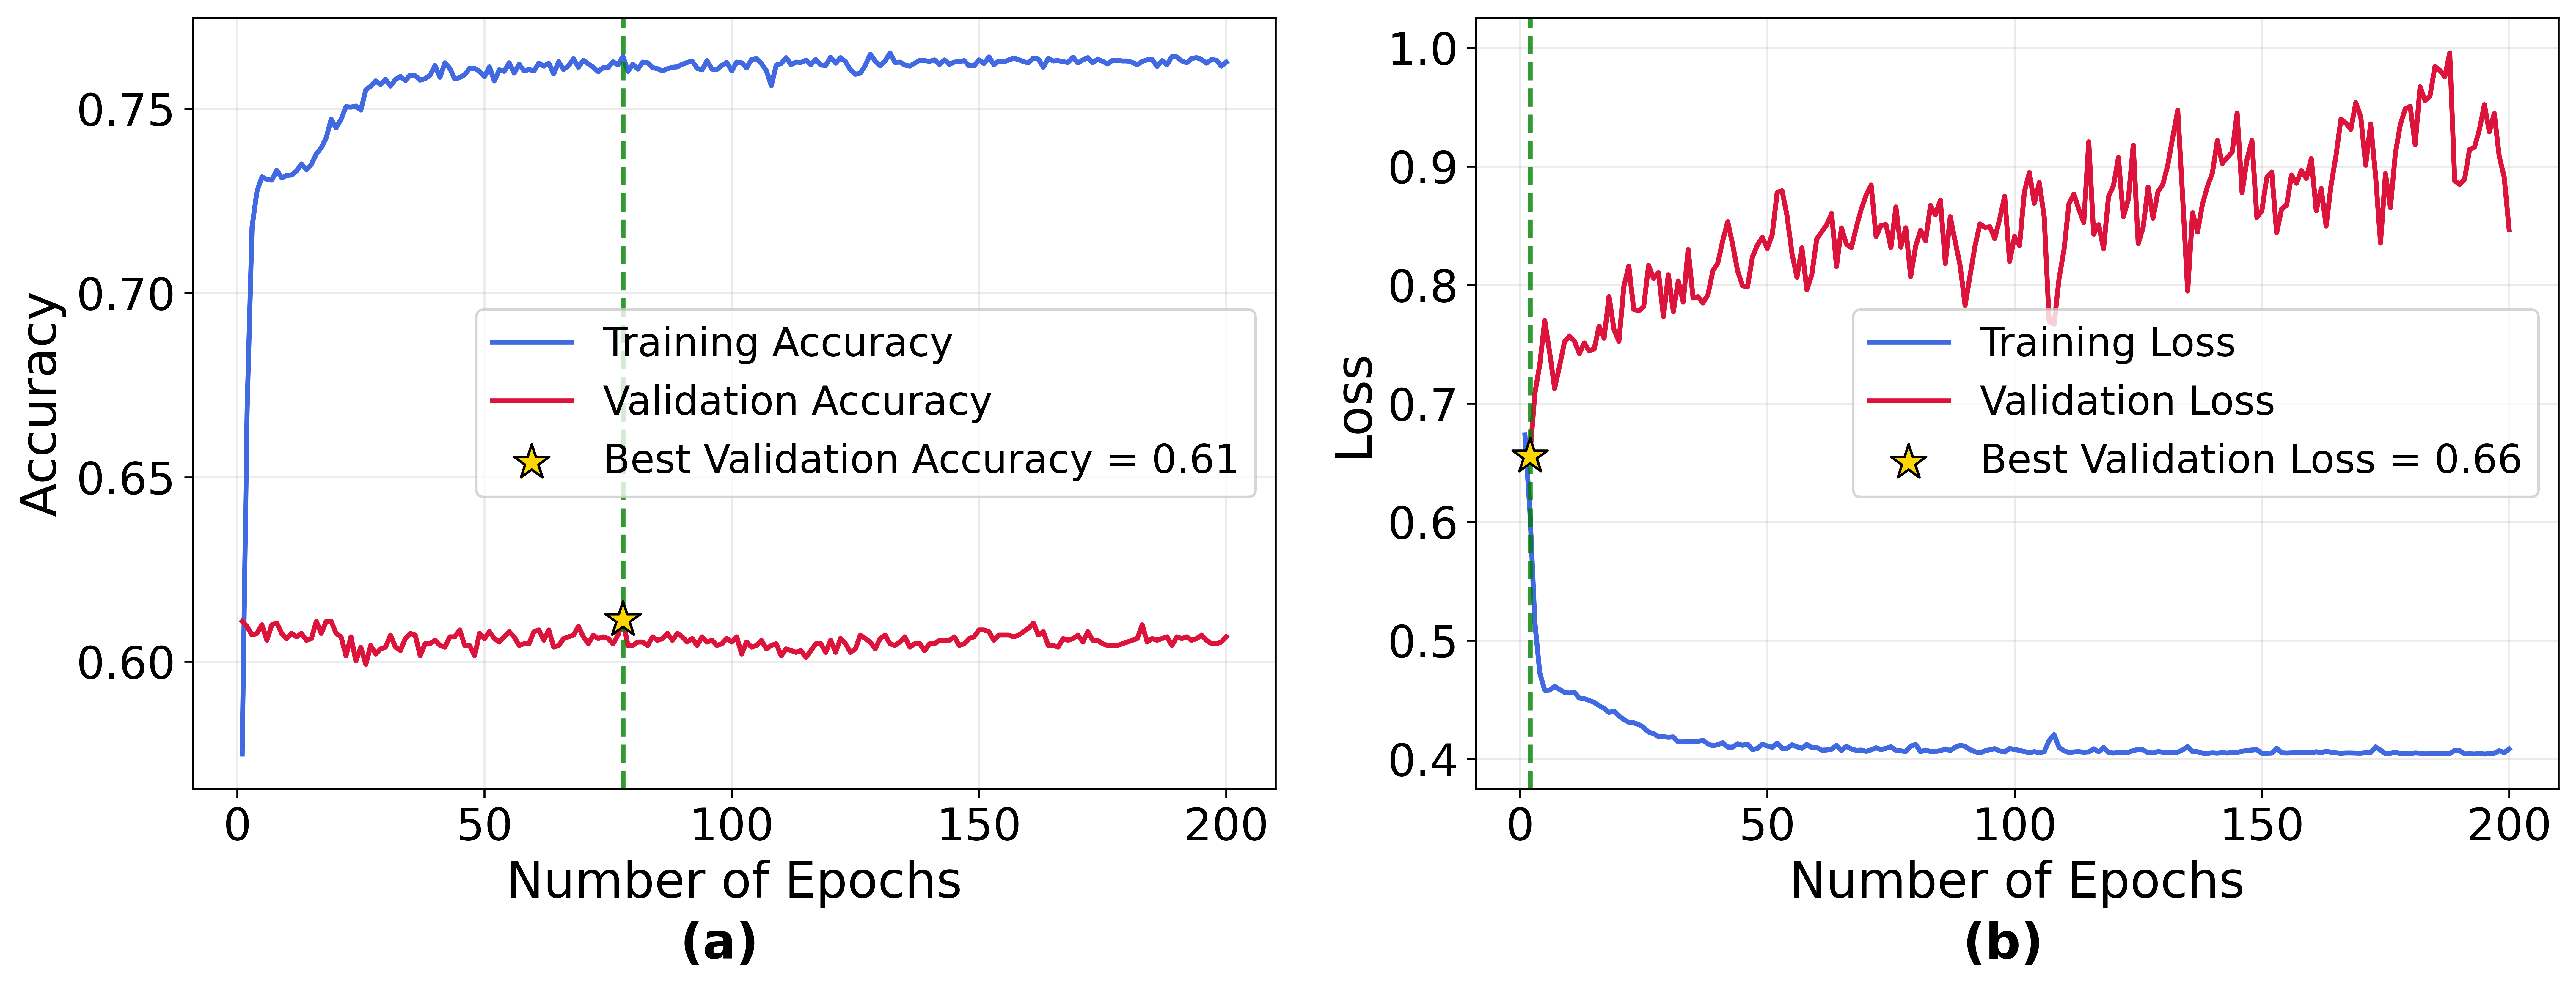

In [15]:
# ============================================================
# Font Settings
# ============================================================
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

# ============================================================
# Identify Best Epochs
# ============================================================

if "epoch" not in df.columns:
    df["epoch"] = range(1, len(df) + 1)

best_acc_idx = df["val_accuracy"].idxmax()
best_acc_epoch = int(df.loc[best_acc_idx, "epoch"])
best_acc = float(df.loc[best_acc_idx, "val_accuracy"])

best_loss_idx = df["val_loss"].idxmin()
best_loss_epoch = int(df.loc[best_loss_idx, "epoch"])
best_loss = float(df.loc[best_loss_idx, "val_loss"])

# ============================================================
# Combined Learning Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=600)

# ============================================================
# Accuracy Plot
# ============================================================
ax1.plot(df["epoch"], df["accuracy"], linewidth=2,
         color="royalblue", label="Training Accuracy")

ax1.plot(df["epoch"], df["val_accuracy"], linewidth=2,
         color="crimson", label="Validation Accuracy")

ax1.axvline(best_acc_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax1.scatter(best_acc_epoch, best_acc,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Accuracy = {best_acc:.2f}")

ax1.set_xlabel("Number of Epochs")
ax1.set_ylabel("Accuracy")
ax1.grid(True, alpha=0.25)
ax1.legend(frameon=True)

# Accuracy plot ticks
for tick, label in zip(ax1.get_xticks(), ax1.get_xticklabels()):
    if int(tick) == best_acc_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Loss Plot
# ============================================================
ax2.plot(df["epoch"], df["loss"], linewidth=2,
         color="royalblue", label="Training Loss")

ax2.plot(df["epoch"], df["val_loss"], linewidth=2,
         color="crimson", label="Validation Loss")

ax2.axvline(best_loss_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax2.scatter(best_loss_epoch, best_loss,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Loss = {best_loss:.2f}")

ax2.set_xlabel("Number of Epochs")
ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.25)
ax2.legend(frameon=True)

# Loss plot ticks
for tick, label in zip(ax2.get_xticks(), ax2.get_xticklabels()):
    if int(tick) == best_loss_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Panel Labels
# ============================================================
ax1.text(0.45, -0.22, "(a)", transform=ax1.transAxes,
         fontsize=20, fontweight="bold")

ax2.text(0.45, -0.22, "(b)", transform=ax2.transAxes,
         fontsize=20, fontweight="bold")

# ============================================================
# Final layout
# ============================================================
fig.tight_layout()

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.png"),
            dpi=600, bbox_inches="tight")

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.pdf"),
            bbox_inches="tight")

plt.show()

### Classification Report

313/313 [==============================] - 1s 3ms/step

Evaluation Results: Train
Accuracy  : 0.763139
Precision : 0.706373
Recall    : 0.899780
F1-score  : 0.791432
ROC AUC   : 0.863750
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.862411  0.626800  0.725967      5000
         1.0   0.706373  0.899780  0.791432      4989

    accuracy                       0.763139      9989
   macro avg   0.784392  0.763290  0.758699      9989
weighted avg   0.784478  0.763139  0.758663      9989



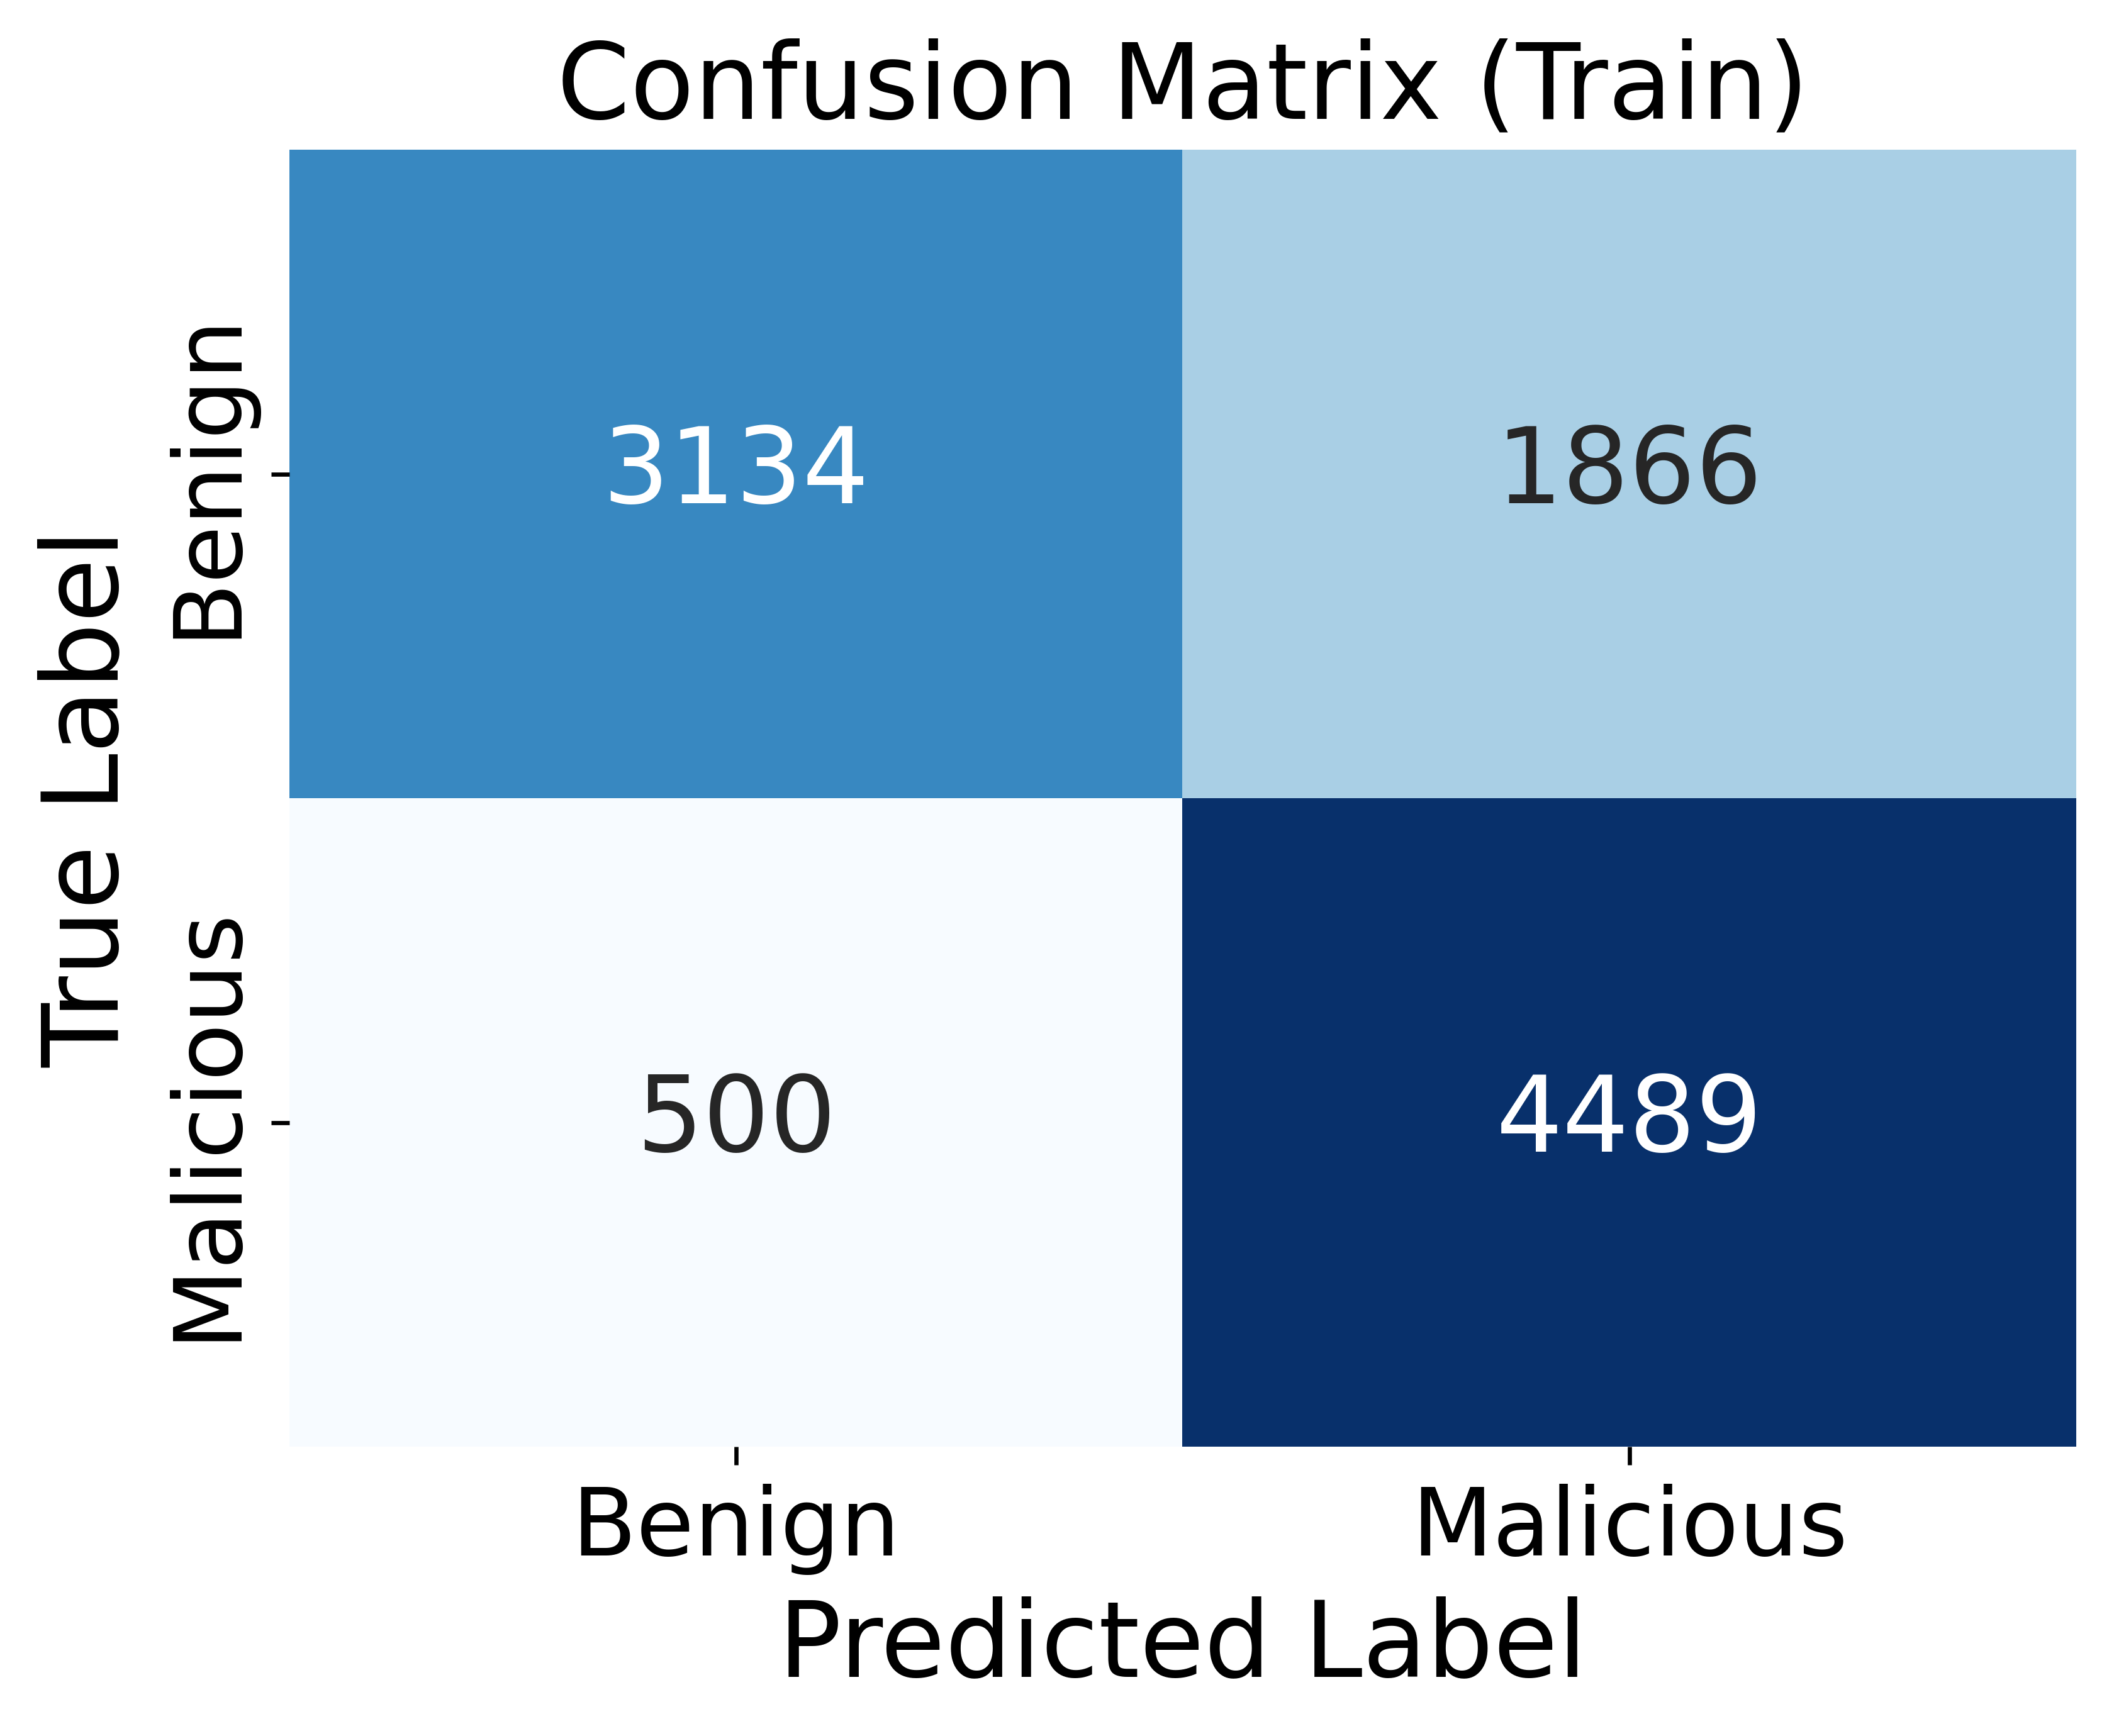

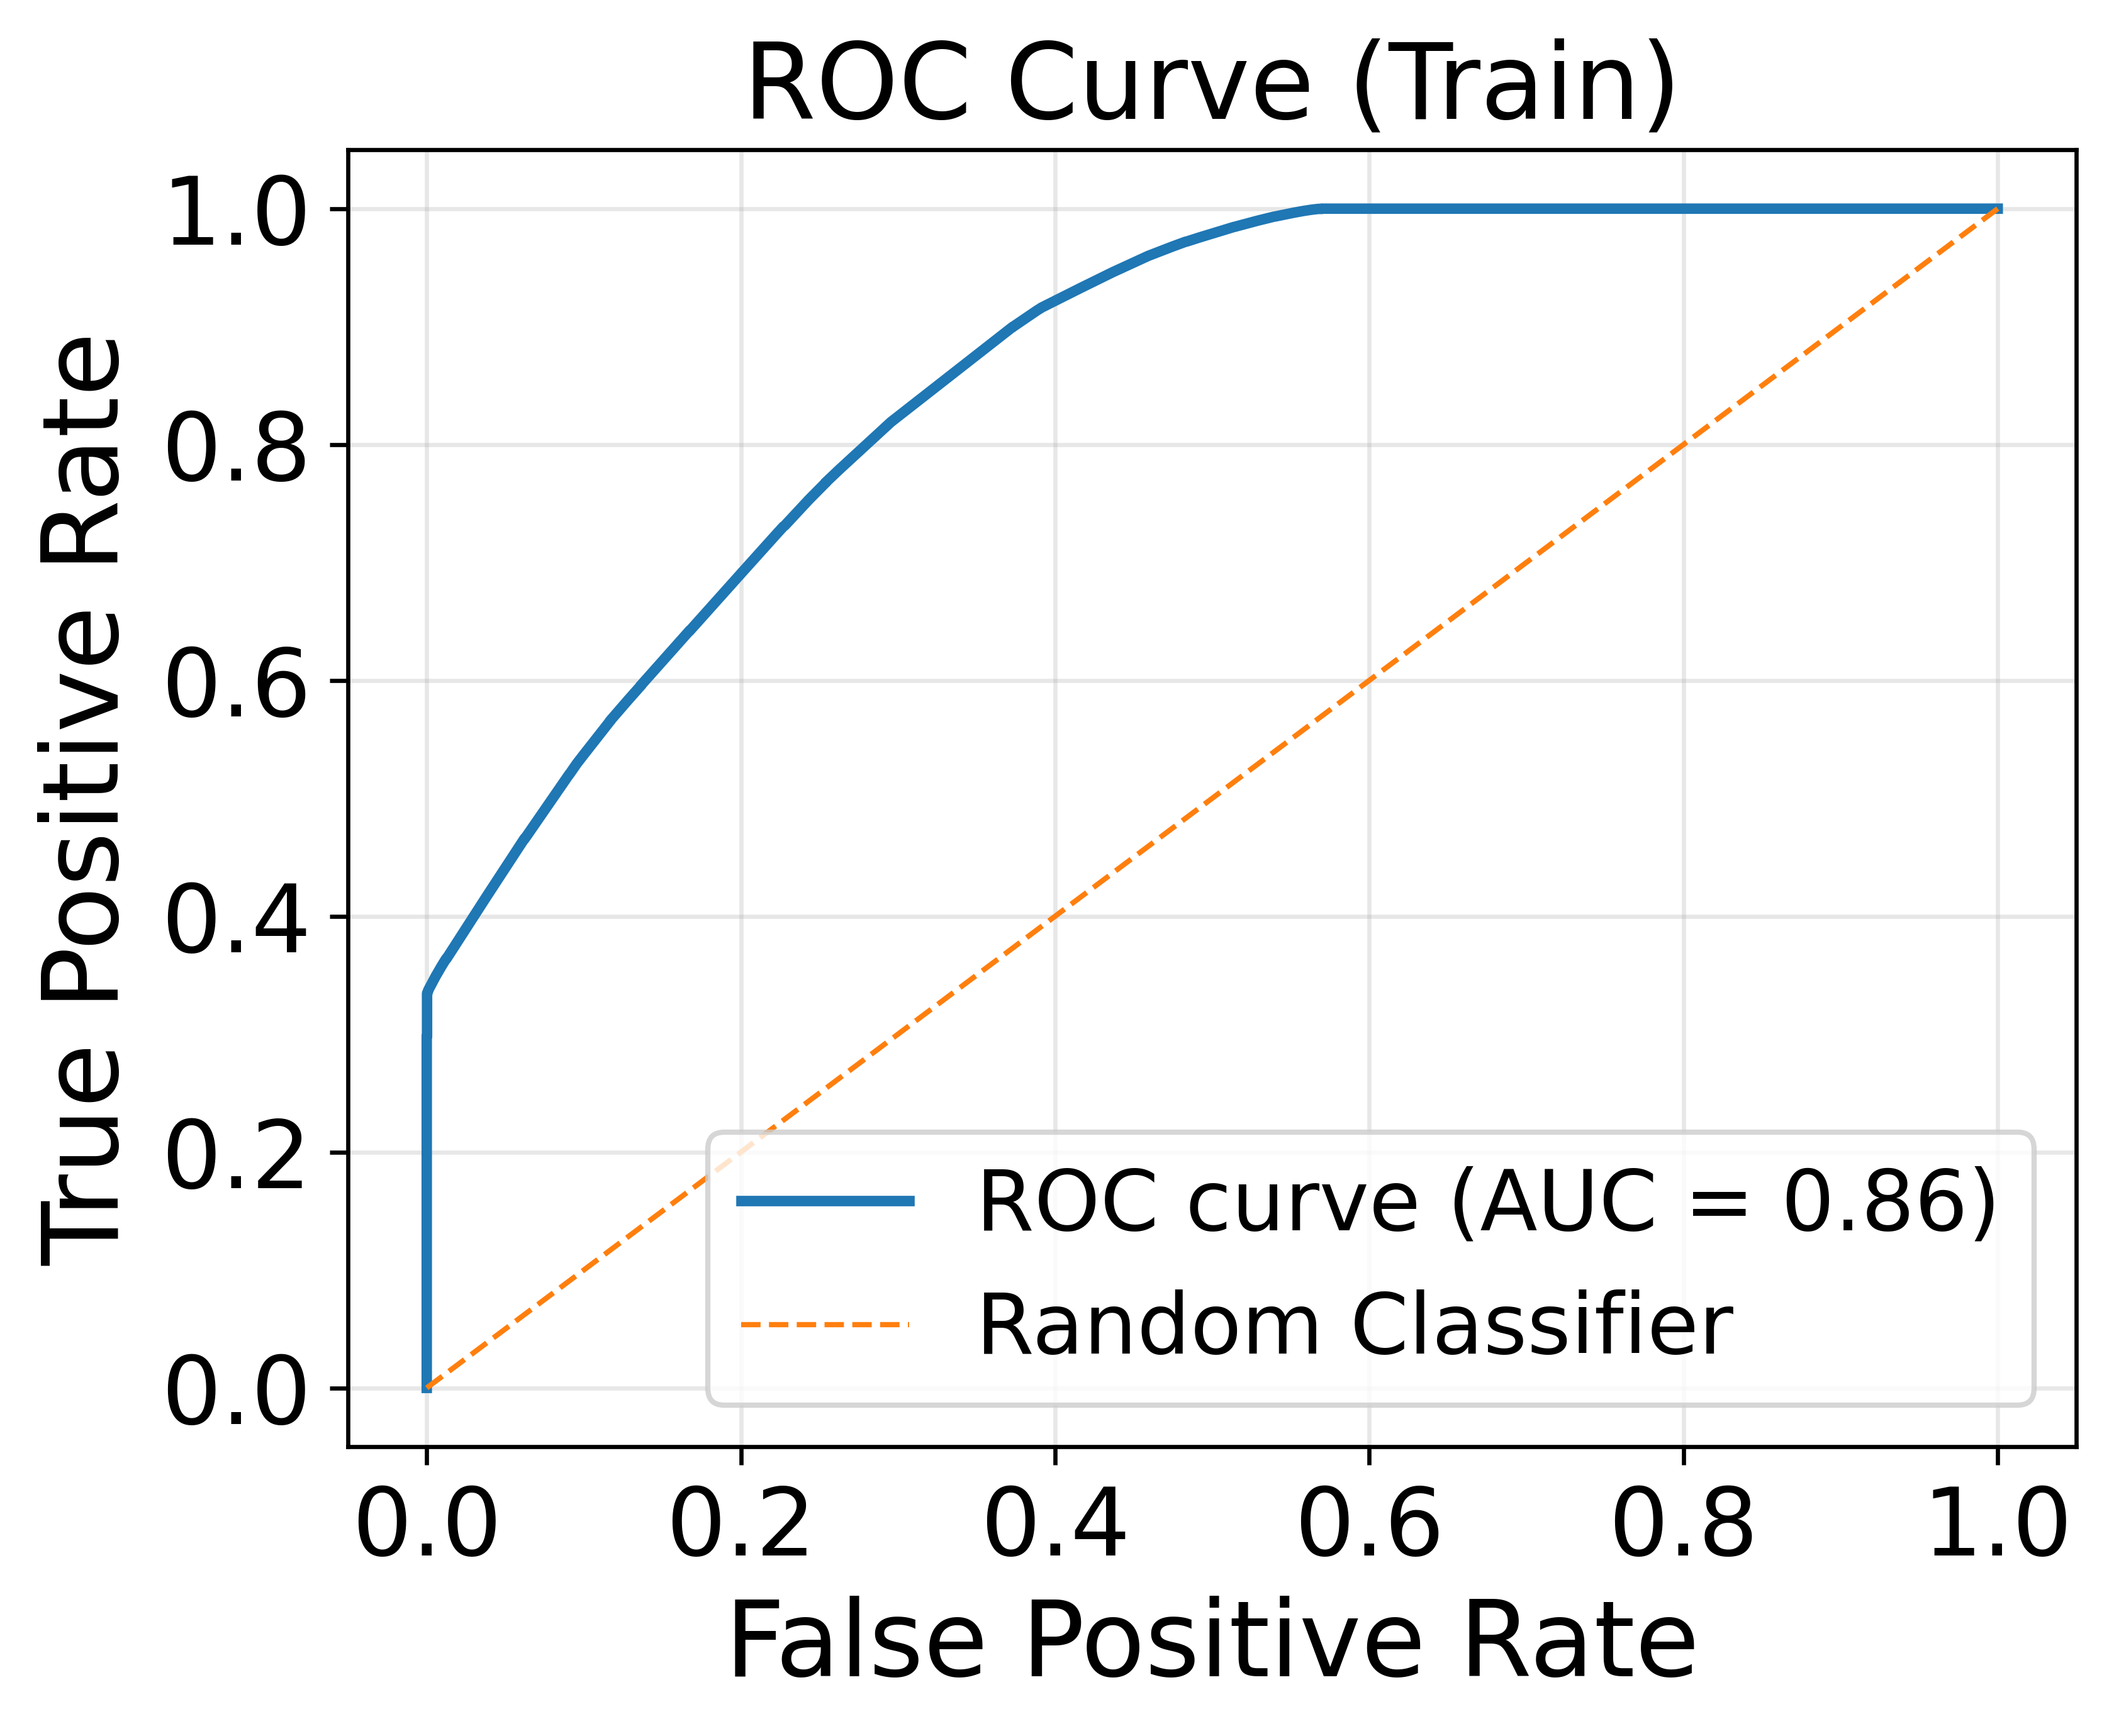

67/67 [==============================] - 0s 3ms/step

Evaluation Results: Validation
Accuracy  : 0.606726
Precision : 0.575415
Recall    : 0.810103
F1-score  : 0.672883
ROC AUC   : 0.645717
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.680818  0.403918  0.507026      1072
         1.0   0.575415  0.810103  0.672883      1069

    accuracy                       0.606726      2141
   macro avg   0.628116  0.607010  0.589954      2141
weighted avg   0.628190  0.606726  0.589838      2141



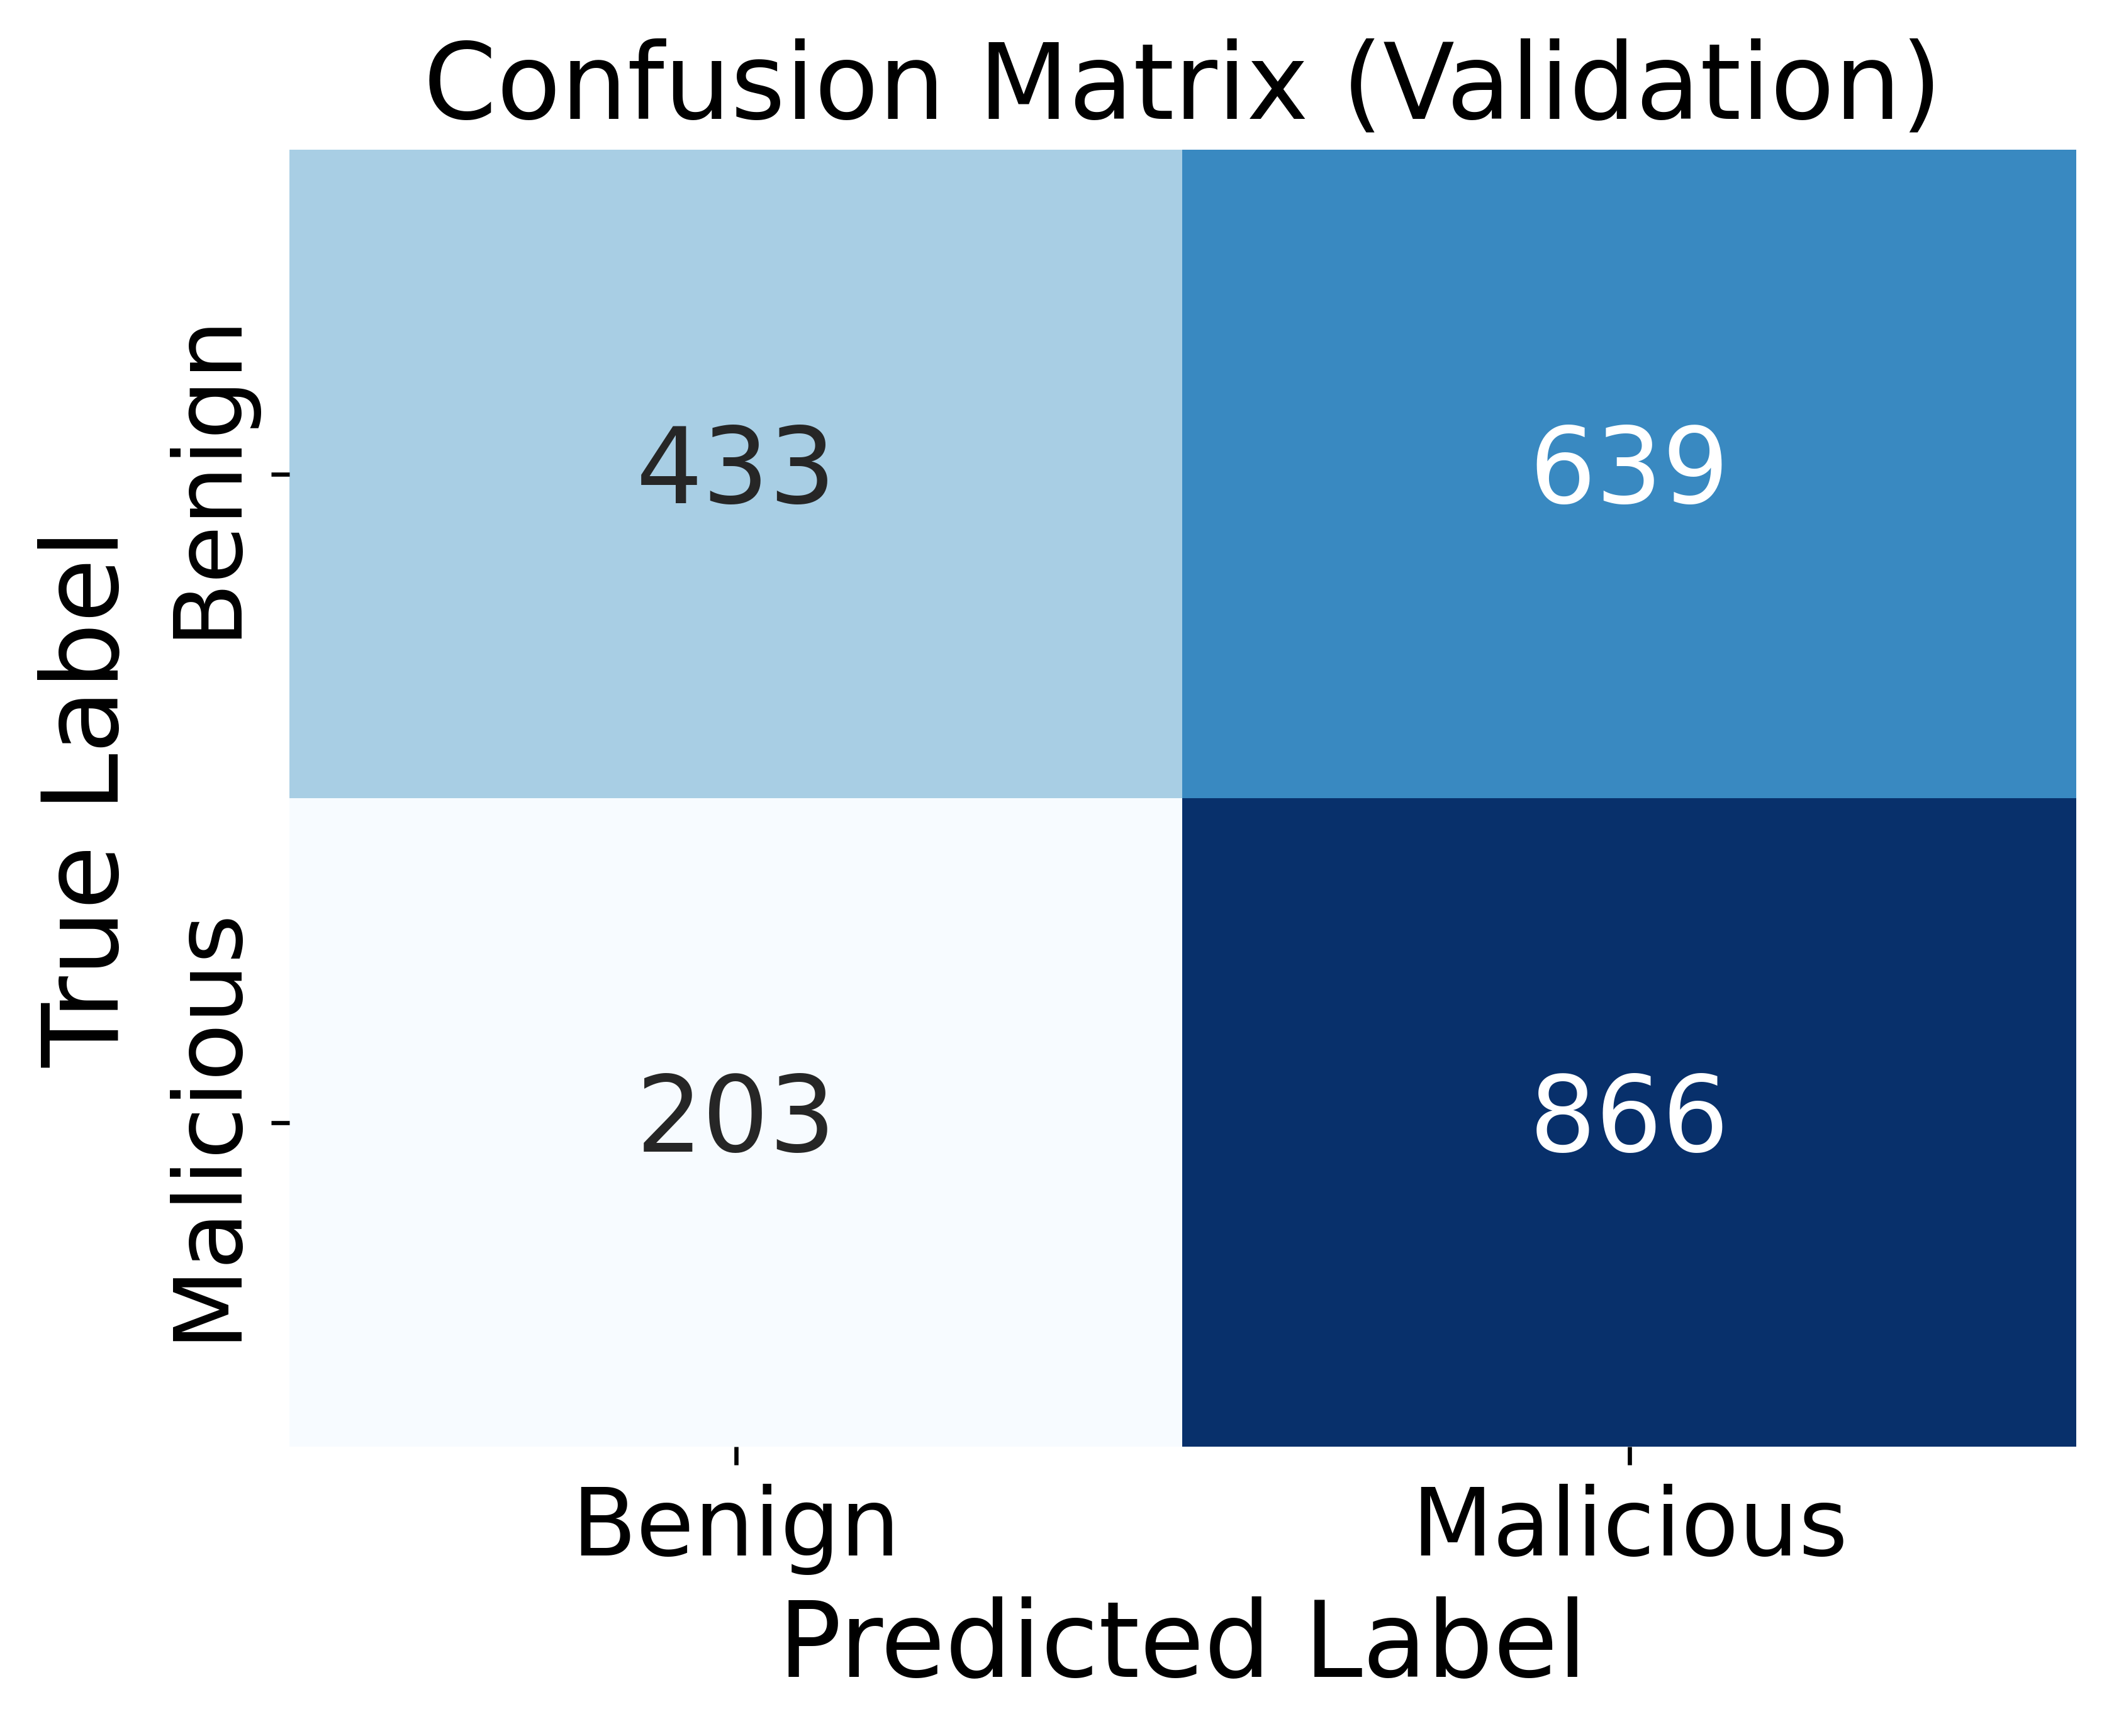

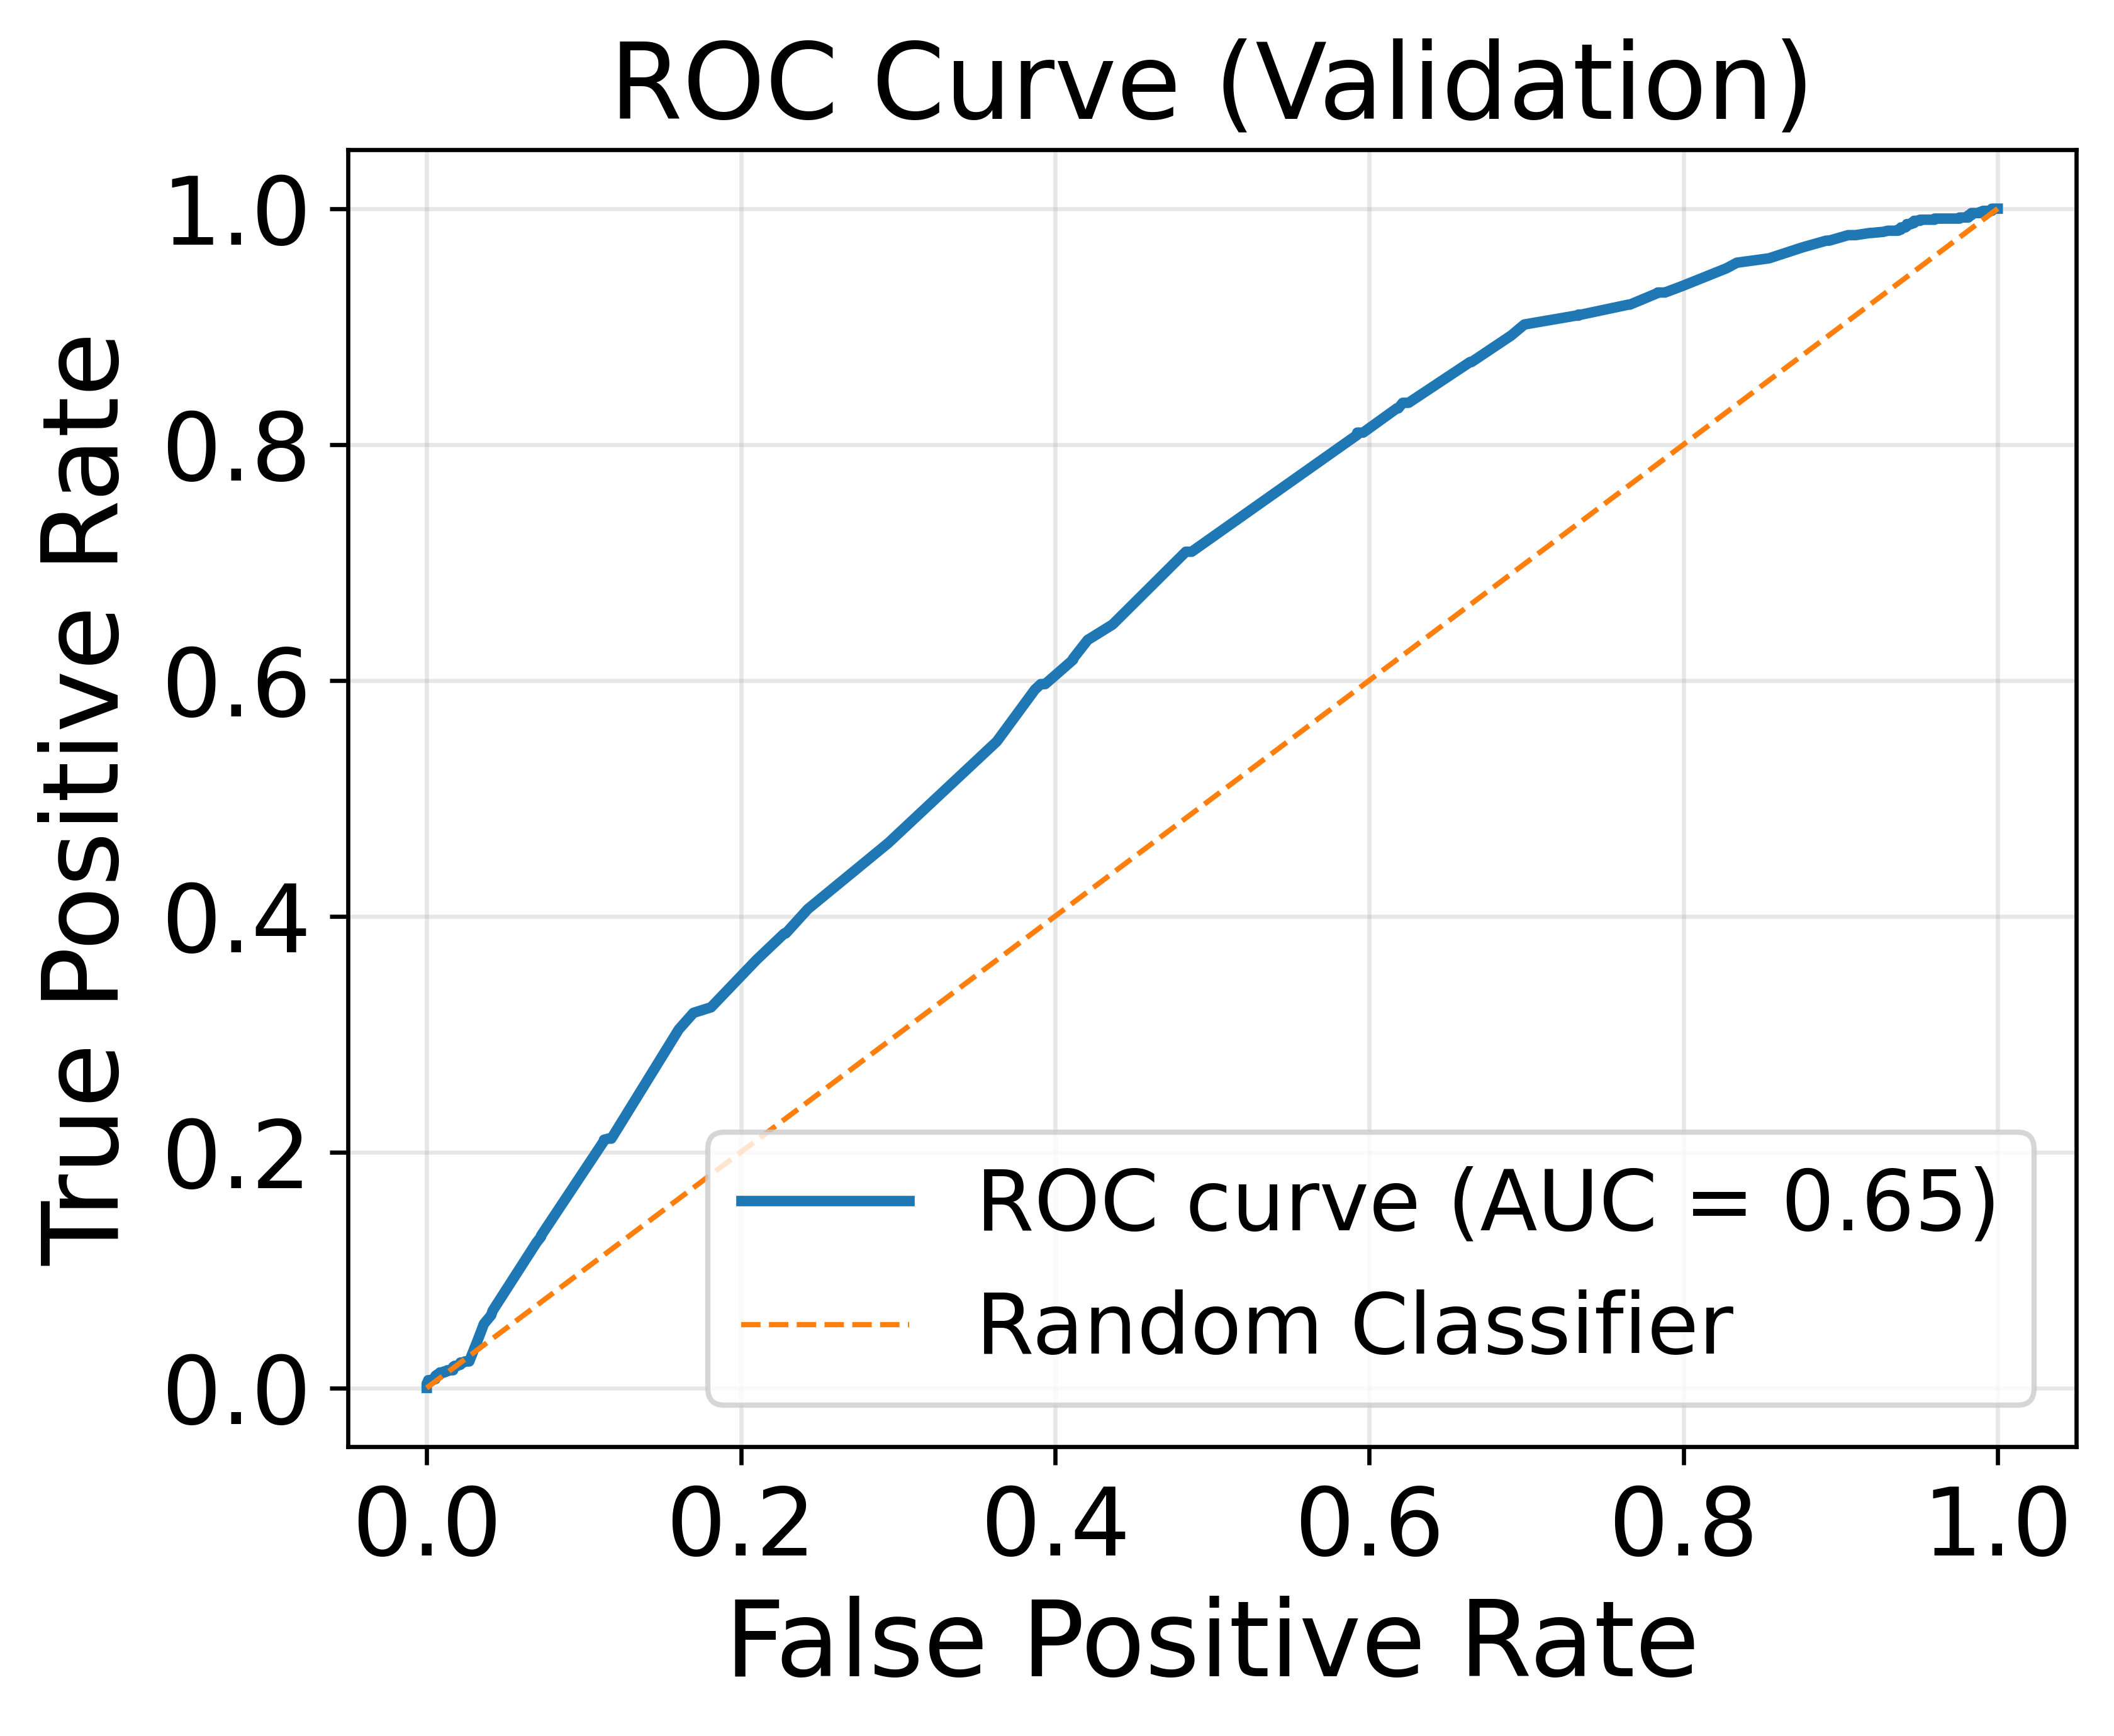

67/67 [==============================] - 0s 4ms/step

Evaluation Results: Test
Accuracy  : 0.607193
Precision : 0.573265
Recall    : 0.834425
F1-score  : 0.679619
ROC AUC   : 0.631795
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.697436  0.380597  0.492456      1072
         1.0   0.573265  0.834425  0.679619      1069

    accuracy                       0.607193      2141
   macro avg   0.635350  0.607511  0.586038      2141
weighted avg   0.635437  0.607193  0.585907      2141



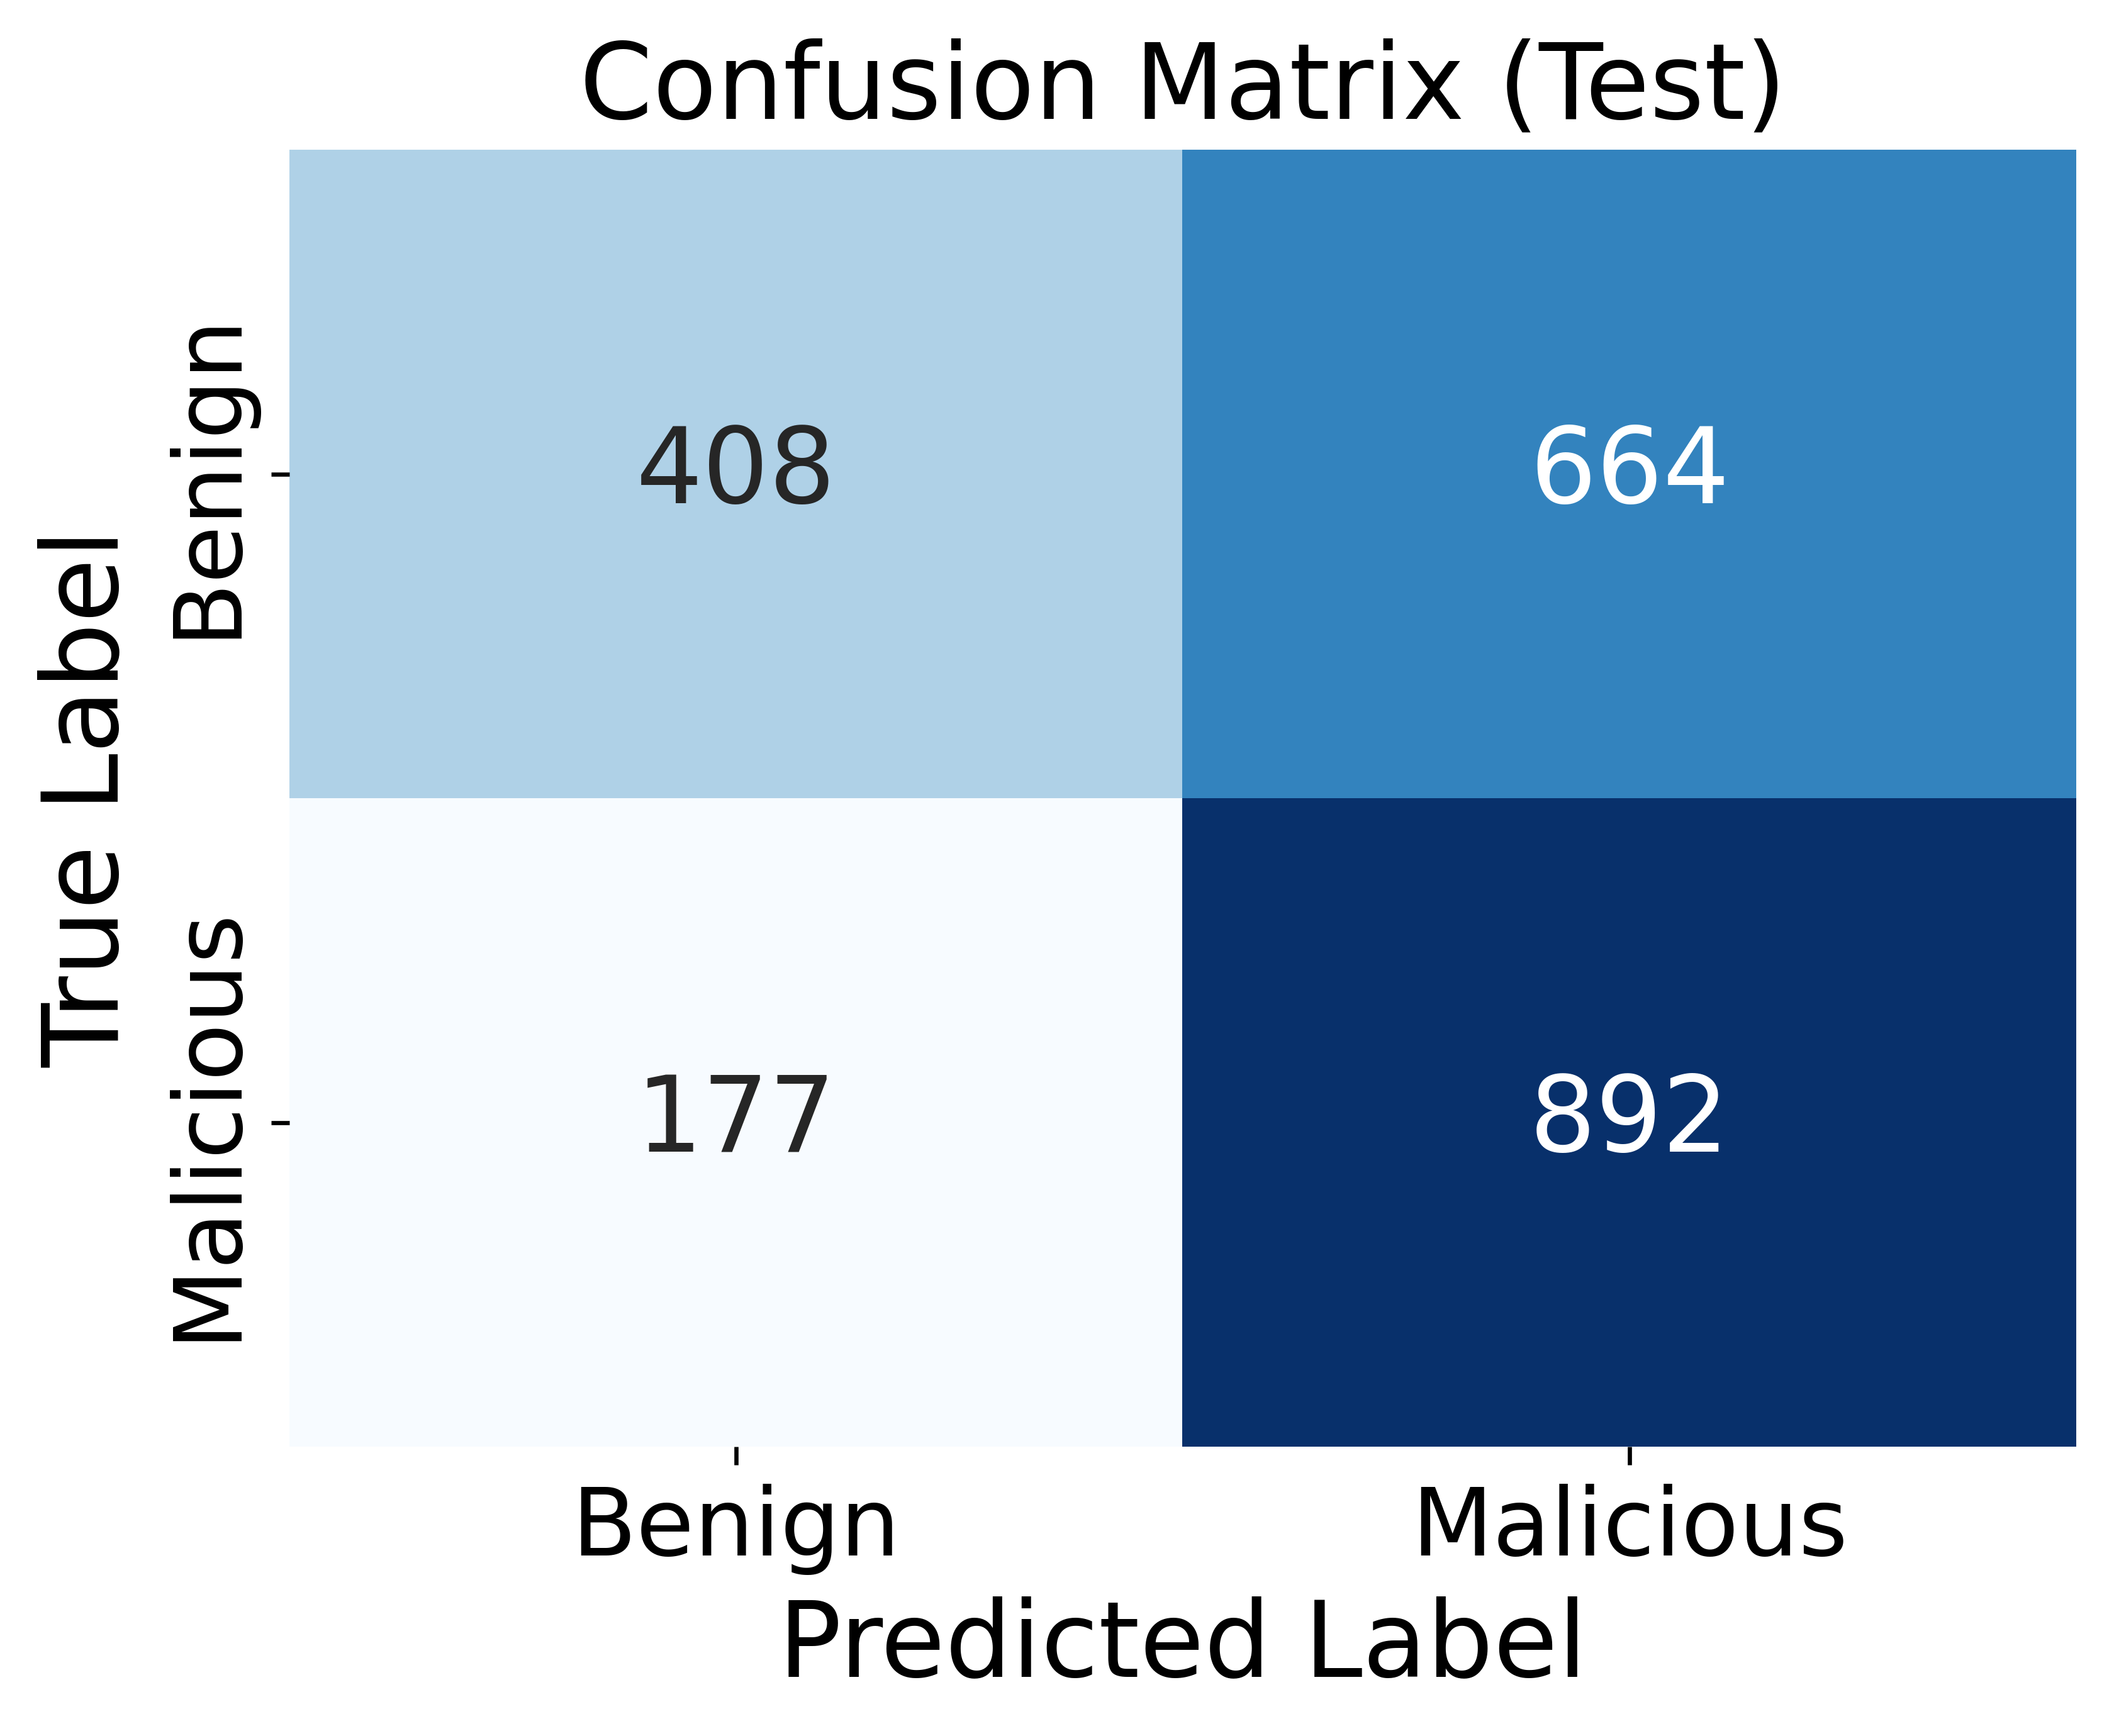

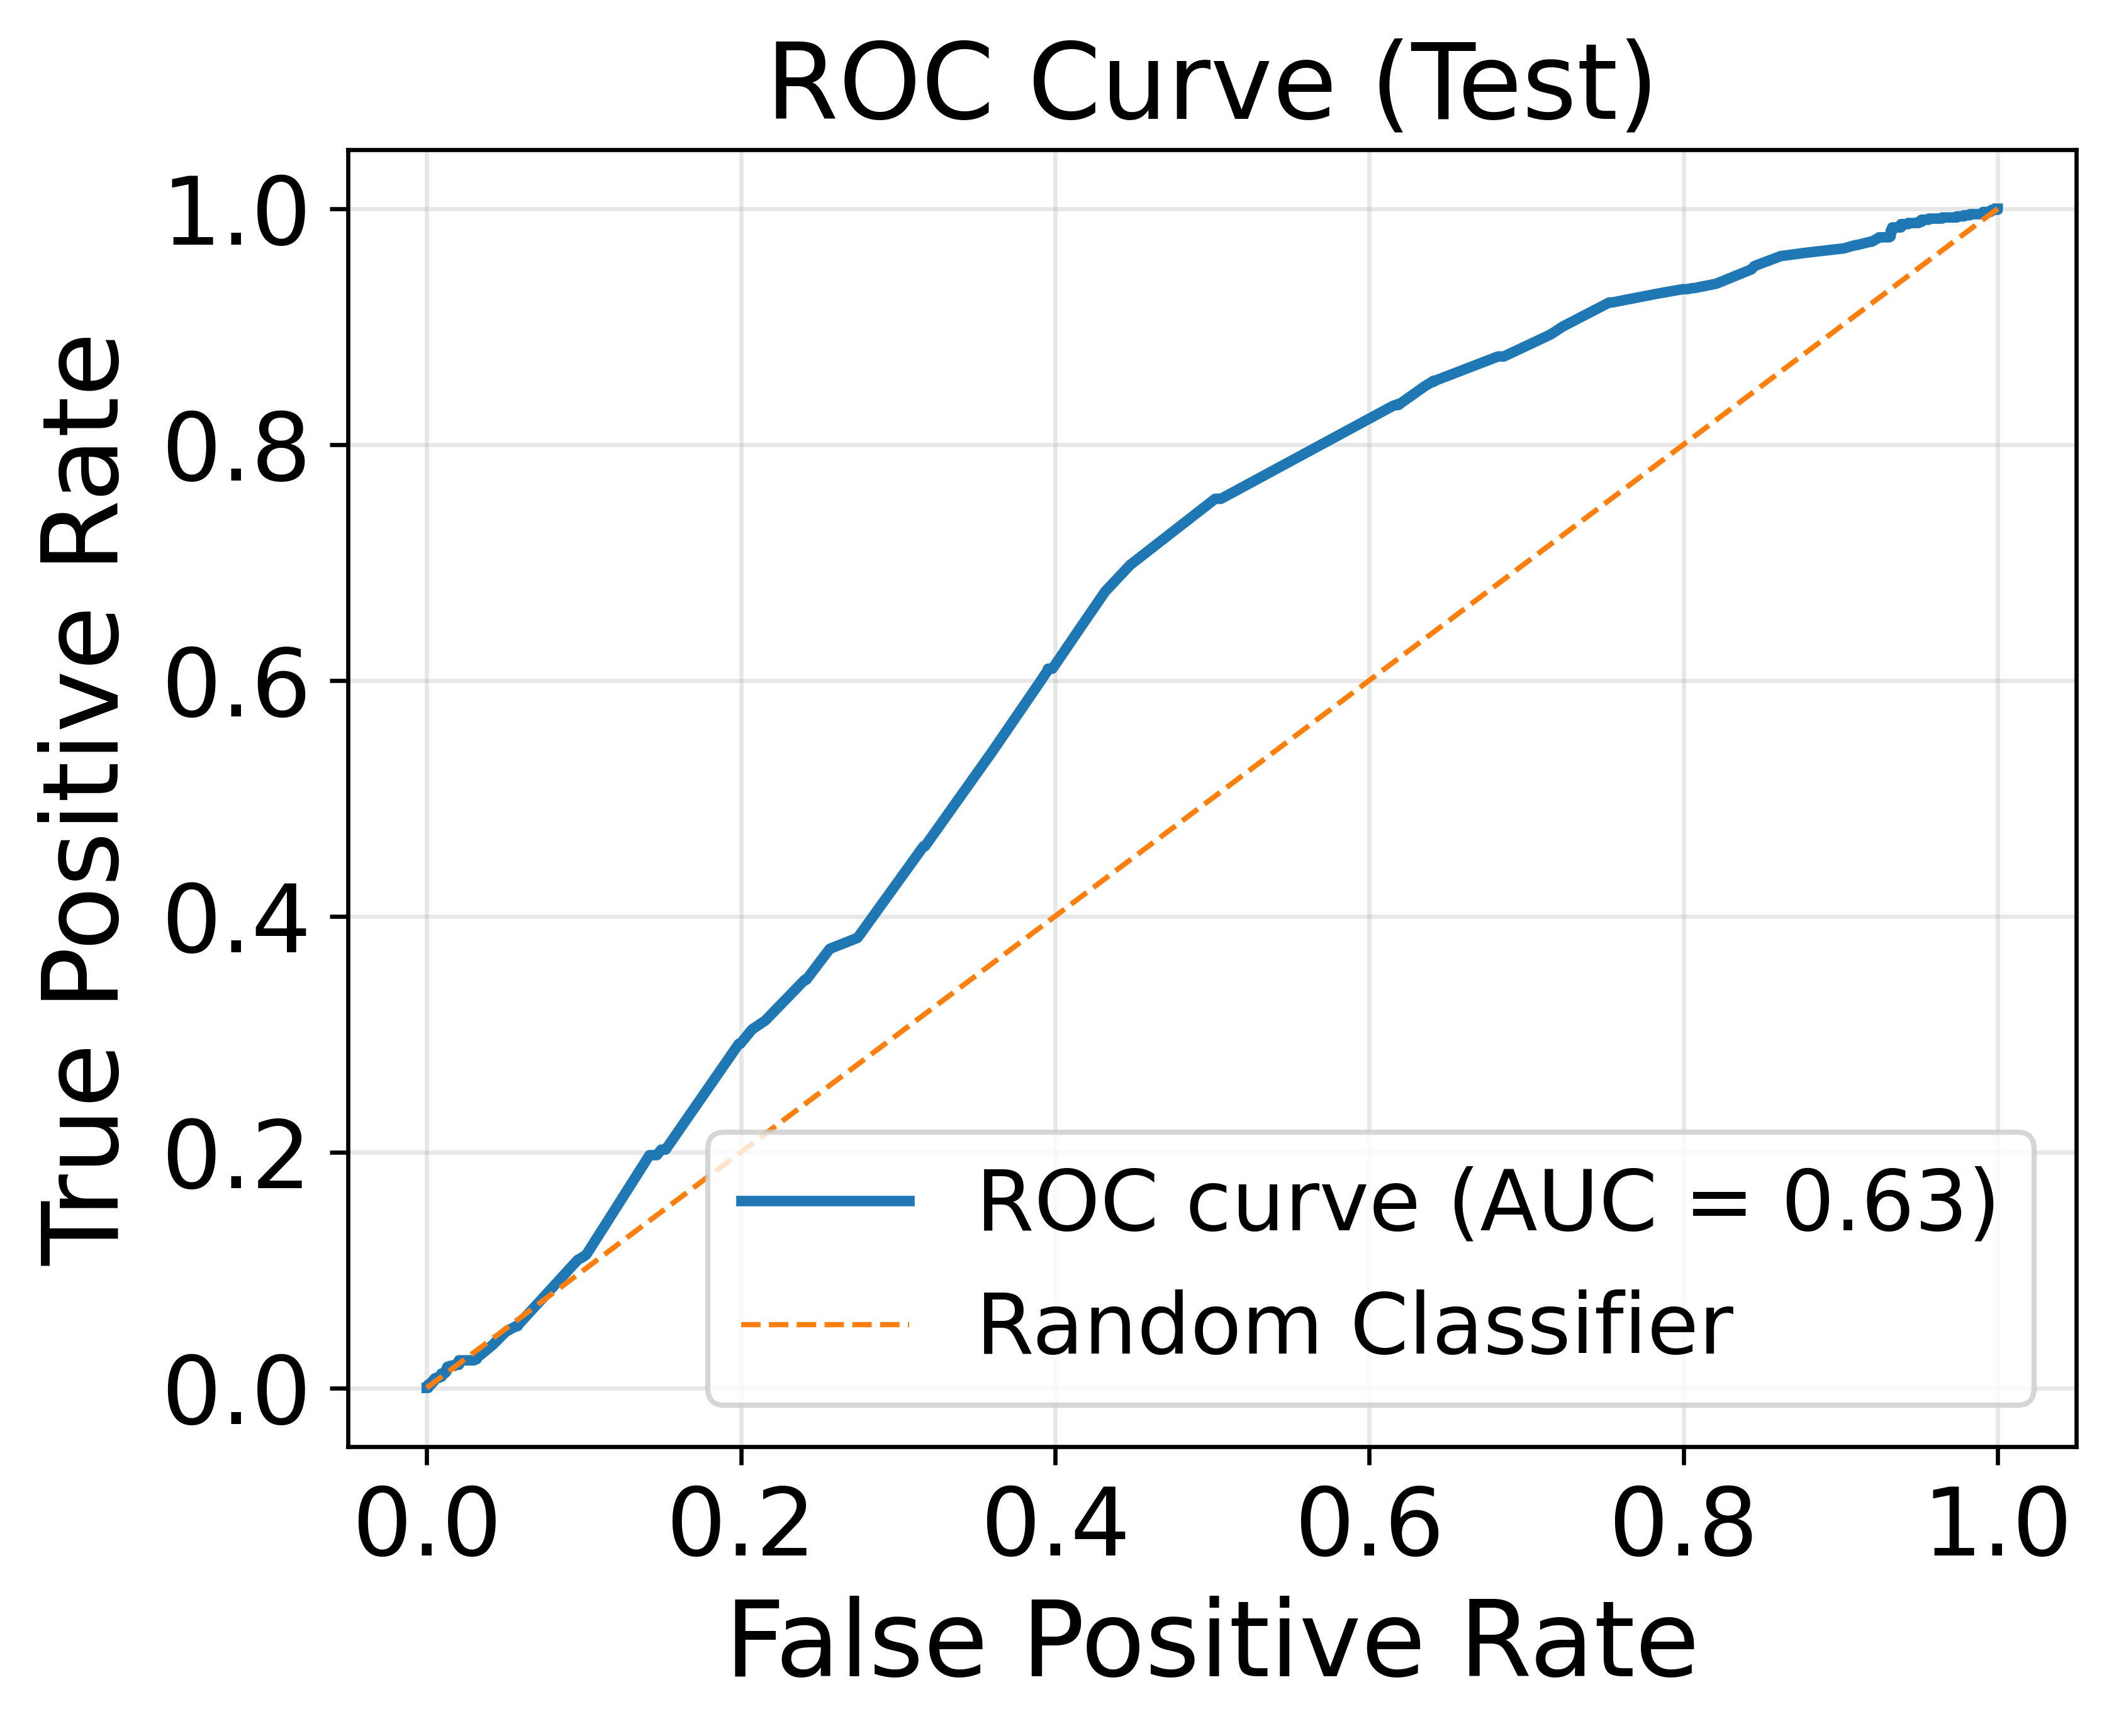

In [16]:
def evaluate_and_plot(model, X, y_true, dataset_name, output_dir=OUTPUT_DIR):
    """
    Evaluate the trained model on a given dataset and generate
    publication-quality confusion matrix and ROC curve figures.

    Parameters
    ----------
    model : keras.Model
        Trained classification model.
    encodings : dict or BatchEncoding
        Tokenized transformer inputs containing 'input_ids' and 'attention_mask'.
    y_true : array-like
        Ground-truth labels.
    dataset_name : str
        Name of the dataset split (e.g., 'Train', 'Validation', 'Test').
    output_dir : str, optional
        Directory where evaluation figures will be saved.

    Returns
    -------
    results : dict
        Dictionary containing predictions and evaluation metrics.
    """

    # --------------------------------------------------------
    # Generate predictions
    # --------------------------------------------------------
    y_prob = model.predict(X).ravel()
    y_pred = (y_prob > 0.5).astype("int32")

    # --------------------------------------------------------
    # Compute evaluation metrics
    # --------------------------------------------------------
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=6)

    # --------------------------------------------------------
    # Print evaluation summary
    # --------------------------------------------------------
    print("\n" + "=" * 70)
    print(f"Evaluation Results: {dataset_name}")
    print("=" * 70)
    print(f"Accuracy  : {acc:.6f}")
    print(f"Precision : {prec:.6f}")
    print(f"Recall    : {rec:.6f}")
    print(f"F1-score  : {f1:.6f}")
    print(f"ROC AUC   : {roc_auc:.6f}")
    print("-" * 70)
    print("Classification Report:")
    print(report)

    # --------------------------------------------------------
    # Plot and save confusion matrix
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Benign", "Malicious"],
        yticklabels=["Benign", "Malicious"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({dataset_name})")
    plt.tight_layout()

    cm_png = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.png")
    cm_pdf = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.pdf")
    plt.savefig(cm_png, dpi=600, bbox_inches="tight")
    plt.savefig(cm_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Plot and save ROC curve
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve ({dataset_name})")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    roc_png = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.png")
    roc_pdf = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.pdf")
    plt.savefig(roc_png, dpi=600, bbox_inches="tight")
    plt.savefig(roc_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Return results for further analysis/reporting
    # --------------------------------------------------------
    results = {
        "dataset": dataset_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": np.array(y_true),
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix_png": cm_png,
        "confusion_matrix_pdf": cm_pdf,
        "roc_curve_png": roc_png,
        "roc_curve_pdf": roc_pdf
    }

    return results


# ============================================================
# Evaluate on Training, Validation, and Test Sets
# ============================================================

train_results = evaluate_and_plot(model, X_train_pad, y_train, "Train")
val_results   = evaluate_and_plot(model, X_val_pad, y_val, "Validation")
test_results  = evaluate_and_plot(model, X_test_pad, y_test, "Test")

### Save All Results

In [17]:
# ------------------------------------------------------------
# Create summary DataFrame
# ------------------------------------------------------------
summary_df = pd.DataFrame([
    {
        "Dataset": train_results["dataset"],
        "Accuracy": train_results["accuracy"],
        "Precision": train_results["precision"],
        "Recall": train_results["recall"],
        "F1-score": train_results["f1_score"],
        "ROC AUC": train_results["roc_auc"]
    },
    {
        "Dataset": val_results["dataset"],
        "Accuracy": val_results["accuracy"],
        "Precision": val_results["precision"],
        "Recall": val_results["recall"],
        "F1-score": val_results["f1_score"],
        "ROC AUC": val_results["roc_auc"]
    },
    {
        "Dataset": test_results["dataset"],
        "Accuracy": test_results["accuracy"],
        "Precision": test_results["precision"],
        "Recall": test_results["recall"],
        "F1-score": test_results["f1_score"],
        "ROC AUC": test_results["roc_auc"]
    }
])

# ------------------------------------------------------------
# Define save paths
# ------------------------------------------------------------
csv_path  = os.path.join(OUTPUT_DIR, "evaluation_summary.csv")
xlsx_path = os.path.join(OUTPUT_DIR, "evaluation_summary.xlsx")

# ------------------------------------------------------------
# Save files
# ------------------------------------------------------------
summary_df.to_csv(csv_path, index=False)
summary_df.to_excel(xlsx_path, index=False)

# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------
print("=" * 60)
print("Evaluation summary saved successfully:")
print(f"CSV  : {csv_path}")
print(f"Excel: {xlsx_path}")
print("=" * 60)

# Display table
summary_df

Evaluation summary saved successfully:
CSV  : Evaluation_Outputs_Opensnoop_Corr_Pre_Attention_LSTM\evaluation_summary.csv
Excel: Evaluation_Outputs_Opensnoop_Corr_Pre_Attention_LSTM\evaluation_summary.xlsx


,Dataset,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Train,0.763139,0.706373,0.899780,0.791432,0.863750
1,Validation,0.606726,0.575415,0.810103,0.672883,0.645717
2,Test,0.607193,0.573265,0.834425,0.679619,0.631795


### Clear Final Backend Session

In [18]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()